In [20]:
import ansys.fluent.core as pyfluent
import numpy as np
import os
import matplotlib.pyplot as plt
import icem_runner as ir

In [21]:
Re = 6500000
T = 300
target_cya = 0.5
Mach = 0.75
cya_tol = 0.0005
cxa_tol = 0.0001
file_name = r"E:/tsagi_dipl/Diploma_bac/optimisation_working_folder/curropt-report.out"
icem_exe = r"E:\Program files\ANSYS Inc\v242\icemcfd\win64_amd\bin\icemcfd.bat"
rpl_script_path = r"E:/tsagi_dipl/Diploma_bac/optimisation_working_folder/airfoil_mesh_script.rpl"
conv_iter = 40

In [28]:
solver_session = pyfluent.launch_fluent(processor_count= 10, dimension = 2, precision= "double", case_file_name =r"E:\tsagi_dipl\Diploma_bac\optimisation_working_folder\optimization_setup.cas.h5",
                                        show_gui= True, start_transcript = False)

c:\Users\vova1\AppData\Local\Programs\Python\Python312\Lib\site-packages\ansys\fluent\core\utils\deprecate.py:118: PyFluentDeprecationWarning: 'show_gui' is deprecated. Use 'ui_mode' instead.
  return func(*args, **kwargs)
pyfluent.general WARNING: Using 'ui_mode = UIMode.GUI' for 'launch_fluent()' instead of 'show_gui = True'.


'file' is deprecated. Use 'settings.file' instead.


In [27]:
if not ir.run_icem(icem_exe, rpl_script_path):
        print(f"[Worker] Ошибка сетки ICEM.")

In [29]:
solver_session.file.replace_mesh(file_name = r"E:\tsagi_dipl\Diploma_bac\optimisation_working_folder\geom.msh")

In [30]:
solver_session.settings.parameters.input_parameters.expression["alpha"].value = 0
solver_session.settings.parameters.input_parameters.expression["Re"].value = Re
solver_session.settings.parameters.input_parameters.expression["Mach"].value = Mach
solver_session.settings.parameters.input_parameters.expression["Temperature"].value = T

In [31]:
solver_session.settings.parameters.input_parameters.expression["alpha"].value()

0.0

In [32]:
def check_convergence(file_name, tol_cya, tol_cxa, conv_iter):
    """
    Проверяет сходимость Cya и Cxa по последним conv_iter итерациям.
    Возвращает: (bool, float, float) -> (статус сходимости, среднее Cya, среднее Cxa)
    """
    try:
        # 1. Чтение и парсинг файла в numpy array
        with open(file_name, 'r') as f:
            raw = (line.replace('"', '').replace('(', '').replace(')', '').split() for line in f)
            # Фильтруем только строки с данными (где первый элемент - число)
            data = np.array([row for row in raw if row and row[0].isdigit()], dtype=float)
        # Проверка на достаточность данных
        if data.shape[0] < conv_iter:
            print("Недостаточно данных для расчета среднего.")
            return False, 0.0, 0.0
        # Столбцы: 1 -> Cya, 2 -> Cxa
        cya, cxa = data[:, 1], data[:, 2]
        last_cya, last_cxa = cya[-conv_iter*2+1:], cxa[-conv_iter*2+1:],
        # 2. Вычисление скользящего среднего через свертку
        kernel = np.ones(conv_iter) / conv_iter
        # mode='valid' означает, что среднее считается только там, где окно полностью перекрывает данные
        last_ma_cya = np.convolve(last_cya, kernel, mode='valid')
        last_ma_cxa = np.convolve(last_cxa, kernel, mode='valid')      
        # Результирующие средние (последняя точка скользящего среднего)
        final_cya = last_ma_cya[-1]
        final_cxa = last_ma_cxa[-1]
        # 4. Проверка: все средние в окне должны быть в пределах tol от финального среднего
        cya_ok = np.all(np.abs(last_ma_cya - final_cya) <= tol_cya)
        cxa_ok = np.all(np.abs(last_ma_cxa - final_cxa) <= tol_cxa)
        return (cya_ok and cxa_ok), final_cya, final_cxa
    except Exception as e:
    
        return False, 0.0, 0.0

In [33]:
def run_calc(step_iter, cya_tol, cxa_tol):
    solver_session.settings.solution.run_calculation.iterate(iter_count=step_iter)
    converged, cya, cxa = check_convergence(file_name, cya_tol, cxa_tol, conv_iter)  
    while not converged: 
        solver_session.settings.solution.run_calculation.iterate(iter_count=step_iter)
        converged, cya, cxa = check_convergence(file_name, cya_tol, cxa_tol, conv_iter)
    return cya, cxa

In [34]:
solver_session.solution.initialization.initialize()
solver_session.setup.reference_values.compute(from_zone_type = 'pressure-far-field', from_zone_name = 'inlet')
solver_session.tui.solve.report_files.clear_data('integral_char')
cya, cxa = run_calc(100, cya_tol, cxa_tol)
alpha_step = 0.5 
#метод Ньютона для решения 
while(abs(cya-target_cya) > cya_tol):
    alpha_step *= -1
    curralpha = solver_session.settings.parameters.input_parameters.expression["alpha"].value()
    newalpha = curralpha + alpha_step
    solver_session.settings.parameters.input_parameters.expression["alpha"].value = newalpha
    newcya, newcxa = run_calc(50, cya_tol, cxa_tol)
    cya_a = (newcya - cya)/alpha_step
    newalpha = curralpha + (target_cya-cya)/cya_a
    solver_session.settings.parameters.input_parameters.expression["alpha"].value = newalpha
    cya, cxa = run_calc(50, cya_tol, cxa_tol)
print(f"При целевом Суа = {target_cya} получен фактический Cya = {cya} с Cxa = {cxa}")

'solution' is deprecated. Use 'settings.solution' instead.
'setup' is deprecated. Use 'settings.setup' instead.
При целевом Суа = 0.5 получен фактический Cya = 0.49999818948219227 с Cxa = 0.00945167859926633


In [10]:
#поляростроитель 
alpha_min = -4.5
alpha_max = 5
alpha_step = 0.5
cyas = []
cxas = []
alphas = np.arange(alpha_min, alpha_max, alpha_step, dtype=float)
solver_session.solution.initialization.initialize()
solver_session.solution.initialization.hybrid_initialize()
solver_session.setup.reference_values.compute(from_zone_type = 'pressure-far-field', from_zone_name = 'inlet')
solver_session.tui.solve.report_files.clear_data('integral_char')
for alpha in alphas:
    solver_session.settings.parameters.input_parameters.expression["alpha"].value = float(alpha)
    cya, cxa = run_calc(100, cya_tol, cxa_tol)
    print(f"alpha: {alpha}, Cya: {cya}, Cxa: {cxa}")
    cyas.append(cya)
    cxas.append(cxa)
    


'solution' is deprecated. Use 'settings.solution' instead.
'setup' is deprecated. Use 'settings.setup' instead.
alpha: -4.5, Cya: -0.510824148720487, Cxa: 0.02116305792120388
alpha: -4.0, Cya: -0.4593820953775912, Cxa: 0.015974324799594437
alpha: -3.5, Cya: -0.3577827277036506, Cxa: 0.01512213959424943
alpha: -3.0, Cya: -0.2790973093309819, Cxa: 0.012531350772338324
alpha: -2.5, Cya: -0.19261417147628637, Cxa: 0.010698819006355161
alpha: -2.0, Cya: -0.10259186055452656, Cxa: 0.009569484888729936
alpha: -1.5, Cya: -0.011920434850043524, Cxa: 0.009101911962489929
alpha: -1.0, Cya: 0.07790289976432055, Cxa: 0.009011140594729348
alpha: -0.5, Cya: 0.16657821090025643, Cxa: 0.009041721552516398
alpha: 0.0, Cya: 0.25525235638648336, Cxa: 0.009147387184300044
alpha: 0.5, Cya: 0.3440290761380387, Cxa: 0.009333282780111437
alpha: 1.0, Cya: 0.4343272385151362, Cxa: 0.009629198614760722
alpha: 1.5, Cya: 0.5266387874182554, Cxa: 0.010198581437808902
alpha: 2.0, Cya: 0.6224750443948228, Cxa: 0.01126

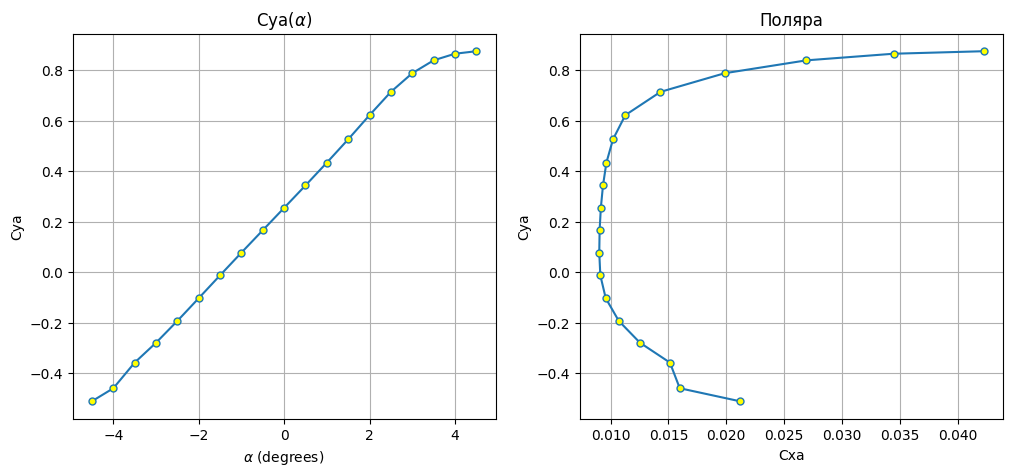

In [12]:
solver_session.settings.solution.monitor.report_files['integral_char'].file_name()#Построение поляры и графика Cya от alpha
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(alphas, cyas, marker='o', ms = 5, markerfacecolor='yellow')
plt.title(r'Cya($\alpha$)')
plt.xlabel(r'$\alpha$ (degrees)')
plt.ylabel('Cya')
plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(cxas, cyas, marker='o', ms = 5,markerfacecolor='yellow')
plt.title('Поляра')
plt.xlabel('Cxa')
plt.ylabel('Cya')
plt.grid(True)


In [133]:
solver_session.tui.solve.report_files.clear_data('integral_char')

In [140]:
file_name